In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import numba
import scipy
import os
import sys
import joblib
import scanpy as sc
from itertools import product, combinations
from collections import defaultdict
from scipy.stats import mannwhitneyu
from pathlib import Path
from adjustText import adjust_text
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap, ListedColormap
from matplotlib.patches import Rectangle
import json

## Plot formatting

In [2]:
path_to_code_repo = "/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER/"
path_to_plot_data = Path("/home/gzu5140/Keerthana_b1042/grnInference/analysisData/figure_5_myeloid_progenitors_50_TF/")
path_to_plot_data.mkdir(exist_ok=True)
path_to_plots = f"/home/gzu5140/Keerthana_b1042/grnInference/plots/figure_5_myeloid_progenitors_50_TF/"
os.makedirs(path_to_plots, exist_ok=True)

In [3]:
# ============================================================
# Fonts / plotting defaults
# ============================================================
import matplotlib.font_manager as fm

font_paths = [
    f"{path_to_code_repo}/fonts//Arial.ttf",
    f"{path_to_code_repo}/fonts//Arial Bold.ttf",
    f"{path_to_code_repo}/fonts//Arial Italic.ttf",
    f"{path_to_code_repo}/fonts//Arial Bold Italic.ttf",
]
for fp in font_paths:
    try:
        fm.fontManager.addfont(fp)
        print("✔ Loaded font:", fp)
    except Exception as e:
        print("⚠️  Could not load:", fp, "|", e)


# ==== LaTeX + SVG text mode (Illustrator-safe) ====
plt.rcParams['pdf.fonttype'] = 42  # For PDF export
plt.rcParams['ps.fonttype'] = 42   # For PostScript (EPS) export
plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['svg.fonttype'] = "none"
plt.rcParams['mathtext.fontset'] = "cm"
plt.rcParams['axes.labelsize'] = 18     # x/y labels
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['xtick.labelsize'] = 12     # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 12    # y-axis tick labels
plt.rcParams['legend.fontsize'] = 12    # legend text

✔ Loaded font: /home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER//fonts//Arial.ttf
✔ Loaded font: /home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER//fonts//Arial Bold.ttf
✔ Loaded font: /home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER//fonts//Arial Italic.ttf
✔ Loaded font: /home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER//fonts//Arial Bold Italic.ttf


In [4]:
def make_reds_blues_colormap(vmin=-0.05, vmax=0.18):
    """Custom red–white–blue colormap with pure white at 0, asymmetric."""
    # Calculate where 0 falls in the range [vmin, vmax]
    zero_position = (0 - vmin) / (vmax - vmin)
    
    # Number of colors for each segment (proportional to range)
    n_total = 256
    n_reds = int(zero_position * n_total)  # colors from vmin to 0
    n_blues = n_total - n_reds  # colors from 0 to vmax
    
    # Calculate intensity based on actual distance from zero
    # For reds: map from vmin to 0, so max intensity at vmin
    red_intensity = abs(vmin) / max(abs(vmin), abs(vmax))  # 0.05/0.18 ≈ 0.28
    # For blues: map from 0 to vmax, so max intensity at vmax  
    blue_intensity = abs(vmax) / max(abs(vmin), abs(vmax))  # 0.18/0.18 = 1.0
    
    # Create color arrays with scaled intensities
    reds = plt.cm.Reds(np.linspace(0.8 * red_intensity, 0, n_reds))  # scaled dark to light red
    whites = np.ones((1, 4))  # pure white at 0
    blues = plt.cm.Blues(np.linspace(0, 0.8 * blue_intensity, n_blues))  # light to scaled dark blue
    
    colors = np.vstack((reds, whites, blues))
    return LinearSegmentedColormap.from_list('RedsBlues', colors)

## Genes of interest

In [5]:
gene_list_Neutrophil = ['Muc13', 'Srgn', 'Ccl9', 'Plac8', 'Snrpf','Prtn3','Elane', 'Igfbp4', 'Ap3s1', 'Ctsg'] #Neutrophil
gene_list_Monocyte = ['Rbms1', 'Tuba1b','Sirpa', 'Ttf1', 'H3f3b', 'Set', 'Tk1', 'Fkbp4', 'Hspd1', 'Emb'] #Monocyte
gene_list_Regulator_TF = ['Gata1', 'Gata2', 'Gfi1', 'Fli1', 'Spi1', 'Tal1',  'Cebpa', 'Jun', 'Egr1', 'Nab2', 'Klf1', 'Zfpm1'] #TF involved in hematopoiesis regulation
gene_list_Pertubation = ['Brd9', 'Wdr82', 'Smarcd2', 'Smarcd1', 'Bcl11a', 'Stag2', 'Setd1b', 'Gps2', 'Men1', 'Chd4', 'Kmt2a', 'Smc2', 'Phf10', 'Cbx3', 'Crebbp', 'Hdac3', 'Setdb2', 'Ehmt2', 'Mbd2', 'Setdb1', 'Rbbp4', 'Hdac1', 'Mbd3', 'Rcor1', 'Atf7ip', 'Hmgxb4', 'Carm1', 'Prmt5', 'Cebpa', 'Ash1l', 'Smarcb1', 'Ezh2', 'Chaf1a', 'Prmt1', 'Ehmt1', 'Smc4', 'Smc3', 'Chmp2a', 'Kdm6a', 'Spi1', 'Gata2']
gene_list_50_genes = ['Ybx1', 'Ttf1', 'Hmgb1', 'Ybx3', 'Nfkb1', 'Hmgb2', 'Srebf2', 'Smarce1', 'Csde1', 'Jund', 'Tsc22d1', 'Max', 'Sp1', 'Bcl11a', 'Irf9', 'Myc', 'Mef2c', 'Ssrp1', 'Tcf4', 'Cbfb', 'Trp53', 'Arid1a', 'Stat3', 'Sub1', 'Mta2', 'Xbp1', 'Cers2', 'Etv6', 'Ubtf', 'Ikzf1', 'Foxp1', 'Smarcc2', 'Dnajc2', 'Zmiz1', 'Nfe2l2', 'Gtf2i', 'Atf4', 'Sox4', 'Cdc5l', 'Zfp422', 'Usf2', 'Mta1', 'Gata2', 'Mafg', 'Creb1', 'Atf2', 'Klf6', 'Runx1', 'Mbd3', 'Rfx7']

## Figure 5b

In [13]:

# ============================
#   1. Significance symbols
# ============================
def get_significance_symbol(pval):
    if pval > 0.05:
        return 'ns'
    elif pval <= 0.0001:
        return '****'
    elif pval <= 0.001:
        return '***'
    elif pval <= 0.01:
        return '**'
    else:
        return '*'

# ============================
#   2. Stat annotation for boxplots
# ============================
def add_stat_annotation(ax, category_a, category_b, label, subset,
                        y_offset=0.05, level=0):
    """
    Draws a significance bracket ABOVE vertical boxplots with clip turned OFF.
    """

    # X-axis category names
    xticklabels = [tick.get_text() for tick in ax.get_xticklabels()]

    if category_a not in xticklabels or category_b not in xticklabels:
        return

    x1 = xticklabels.index(category_a)
    x2 = xticklabels.index(category_b)
    x_min, x_max = min(x1, x2), max(x1, x2)

    # Height for bracket
    ymax = subset['Transcriptomic distance [a.u.]'].max()
    h = ymax * (1 + y_offset + level * 0.12)

    # Bracket line (no clipping)
    ax.plot(
        [x_min, x_min, x_max, x_max],
        [h, h * 1.05, h * 1.05, h],
        lw=1.5,
        color='black',
        clip_on=False
    )

    # Label (no clipping)
    ax.text(
        (x_min + x_max) / 2,
        h * 1.12,
        label,
        ha='center',
        va='bottom',
        fontsize=12,
        clip_on=False
    )

# ============================
#   3. Plot vertical boxplots
# ============================

def plot_vertical_boxplots(df_distances, save_dir = None):

    fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
    plt.subplots_adjust(top=0.83)  # Ensure title + brackets never clip

    timepoints = ['Day 2', 'Day 4', 'Day 6']

    for ax, timepoint in zip(axes, timepoints):

        subset = df_distances[df_distances['timepoint'] == timepoint]

        # -----------------------------
        # Vertical boxplot
        # -----------------------------
        bp = sns.boxplot(
            data=subset,
            x='pair_type',
            y='Transcriptomic distance [a.u.]',
            hue='pair_type',
            palette={'clonal pairs': 'lightgray', 'random pairs': 'gray'},
            ax=ax
        )

        # Disable clipping for every boxplot artist
        for artist in ax.artists + ax.lines:
            artist.set_clip_on(False)

        sns.despine(right=True, top=True, ax=ax)

        ax.set_xlabel('')
        ax.set_ylabel('transcriptomic distance [a.u.]')
        ax.set_title(timepoint, pad=30)  # higher title
        ax.set_ylim(0,62)
        # -----------------------------
        # Mann-Whitney U-test
        # -----------------------------
        clonal = subset[subset['pair_type'] == 'clonal pairs']['Transcriptomic distance [a.u.]']
        random = subset[subset['pair_type'] == 'random pairs']['Transcriptomic distance [a.u.]']

        _, pval = mannwhitneyu(clonal, random, alternative='two-sided')
        label = get_significance_symbol(pval)
        # # -----------------------------
        # # Add significance bracket
        # # -----------------------------
        add_stat_annotation(
            ax=ax,
            category_a='clonal pairs',
            category_b='random pairs',
            label=label,
            subset=subset,
            y_offset=0.05,
            level=0
        )


    # Legend outside (no clipping)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    if save_dir:
        plt.savefig(os.path.join(save_dir, 'twin_random_PCA_dist_day_2.svg'),
                    format='svg',
                    facecolor='none', edgecolor='none', transparent=True)
        plt.savefig(os.path.join(save_dir, 'twin_random_PCA_dist_day_2.pdf'),
                    format='pdf',
                    facecolor='none', edgecolor='none', transparent=True)

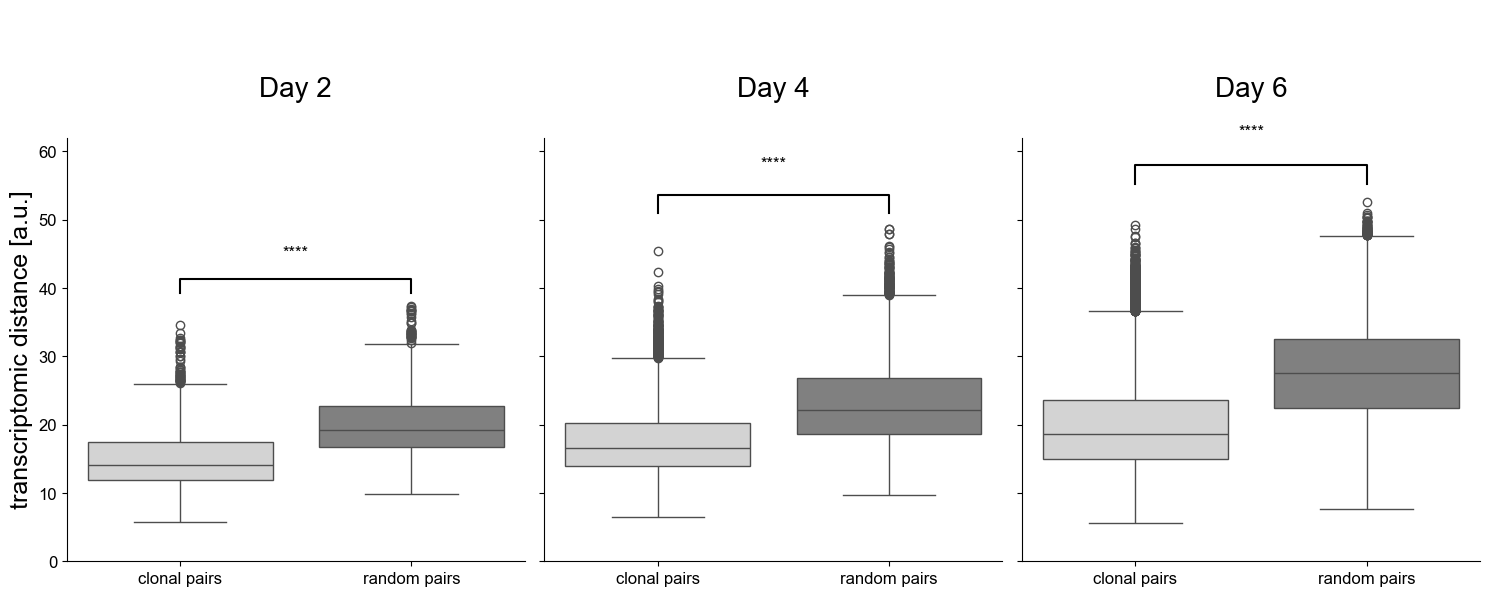

In [30]:
df_distances = pd.read_csv(f"{path_to_plot_data}/twin_vs_random_dist.csv")
plot_vertical_boxplots(df_distances, save_dir = path_to_plots)

## Figure 5c - volcano plots

In [9]:
def volcano_plot(
    df_results,
    pval_threshold = 0.05,
    group = None,
    save_path=None
):
    # -----------------------------
    # Plot
    # -----------------------------
    fig, ax = plt.subplots(figsize=(8, 6))

    # Non-significant (grey)
    sns.scatterplot(
        data=df_results[~df_results["significant"]],
        x="logFC",
        y="neg_log10_pval",
        style="gene_group",
        markers={
            "Neutrophil": "s",
            "Monocyte": "D",
            "Regulatory TF": "^",
            "More TF": "X"
        },
        color="lightgray",
        edgecolor=None,
        legend=False,
        clip_on=False,
        ax=ax
    )

    # Significant (colored)
    sns.scatterplot(
        data=df_results[df_results["significant"]],
        x="logFC",
        y="neg_log10_pval",
        hue="gene_group",
        style="gene_group",
        palette={
            "Neutrophil": "#56B4E9",
            "Monocyte": "#CC79A7",
            "Regulatory TF": "#009E73",
            "More TF": "gray"
        },
        markers={
            "Neutrophil": "s",
            "Monocyte": "D",
            "Regulatory TF": "^",
            "More TF": "X"
        },
    edgecolor='none',  # ← Change from None to 'none'
    linewidth=0,       # ← Add this for extra assurance
    clip_on=False,
    ax=ax
    )

    # -----------------------------
    # Text labels (no clipping)
    # -----------------------------
    texts = []
    for _, row in df_results[df_results["significant"]].iterrows():
        texts.append(
            ax.text(
                row["logFC"],
                row["neg_log10_pval"],
                row["gene"],
                fontsize=14,
                clip_on=False
            )
        )

    adjust_text(
    texts,
    ax=ax,
    move_only={'text': 'xy'},   # move labels only
    expand_text=(1.1, 1.1),    # minimal label–label repulsion
    expand_points=(1.0, 1.0),   # DO NOT push labels away from points
    force_text=(0.1, 0.4),      # gentle adjustment
    )

    # -----------------------------
    # Threshold line
    # -----------------------------
    ax.axhline(
        y=-np.log10(pval_threshold),
        color="green",
        linestyle="--",
        clip_on=False
    )

    # -----------------------------
    # Styling
    # -----------------------------
    sns.despine(ax=ax, right=True, top=True)
    ax.set_title(f"{group}")
    ax.set_xlabel("log2 fold change")
    ax.set_ylabel("-log10 p-value")

    ax.legend(
        title="Gene Groups",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        frameon=False
    )

    # -----------------------------
    # Save & show
    # -----------------------------
    if save_path:
        path_to_plot = f"{save_path}/volcano_plot_{group}.pdf"
        plt.savefig(path_to_plot, 
            format='pdf', 
            bbox_inches='tight',
            facecolor='none',      # Transparent figure background
            edgecolor='none',      # No edge color
            transparent=True)      # Ensure transparency
    plt.show()

    return 

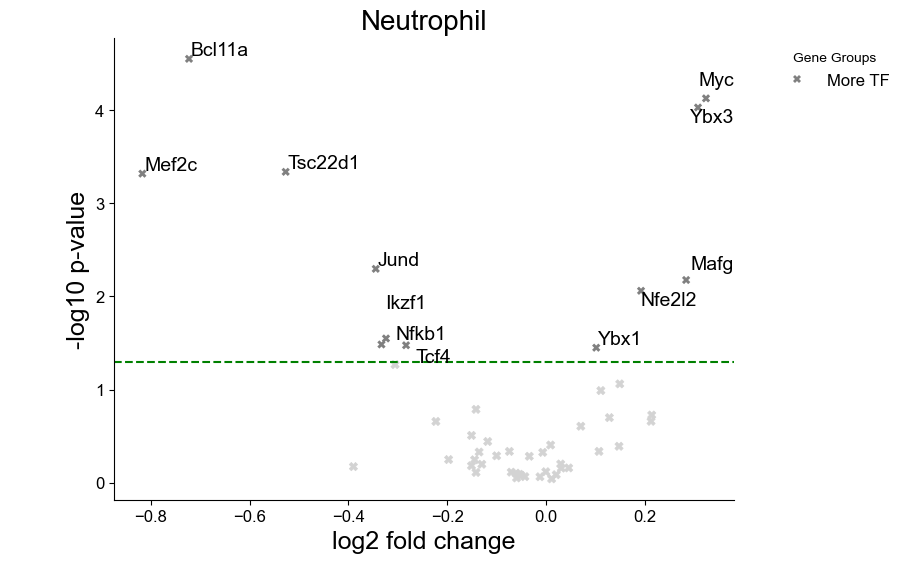

In [10]:
#volcano plot for Neutrophils
cell_type = "Neutrophil"
df_neutrophils = pd.read_csv(f"{path_to_plot_data}/volcano_plot_{cell_type}_myeloid_50_genes.csv")
volcano_plot(df_neutrophils, group = cell_type, save_path = path_to_plots)

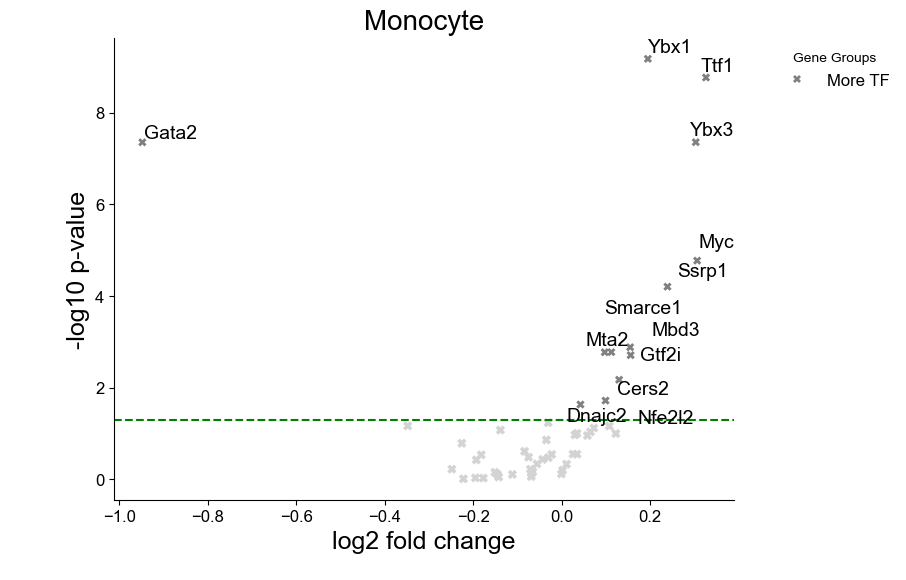

In [11]:
#volcano plot for Neutrophils
cell_type = "Monocyte"
df_monocyte = pd.read_csv(f"{path_to_plot_data}/volcano_plot_{cell_type}_myeloid_50_genes.csv")
volcano_plot(df_monocyte, group = cell_type, save_path = path_to_plots)

## Figure 5d

In [12]:
scenario_order = [
    "self",
    "single-state, no regulation",
    "single-state, regulation",
    "multiple states",
]

scenario_colors = {
    "self": "lightgrey",
    "single-state, no regulation": "#9e9e9e",
    "single-state, regulation": "#0072b2",
    "multiple states": "#d55e00",
}



/tmp/ipykernel_303465/4146698923.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(gene_list, rotation=90)


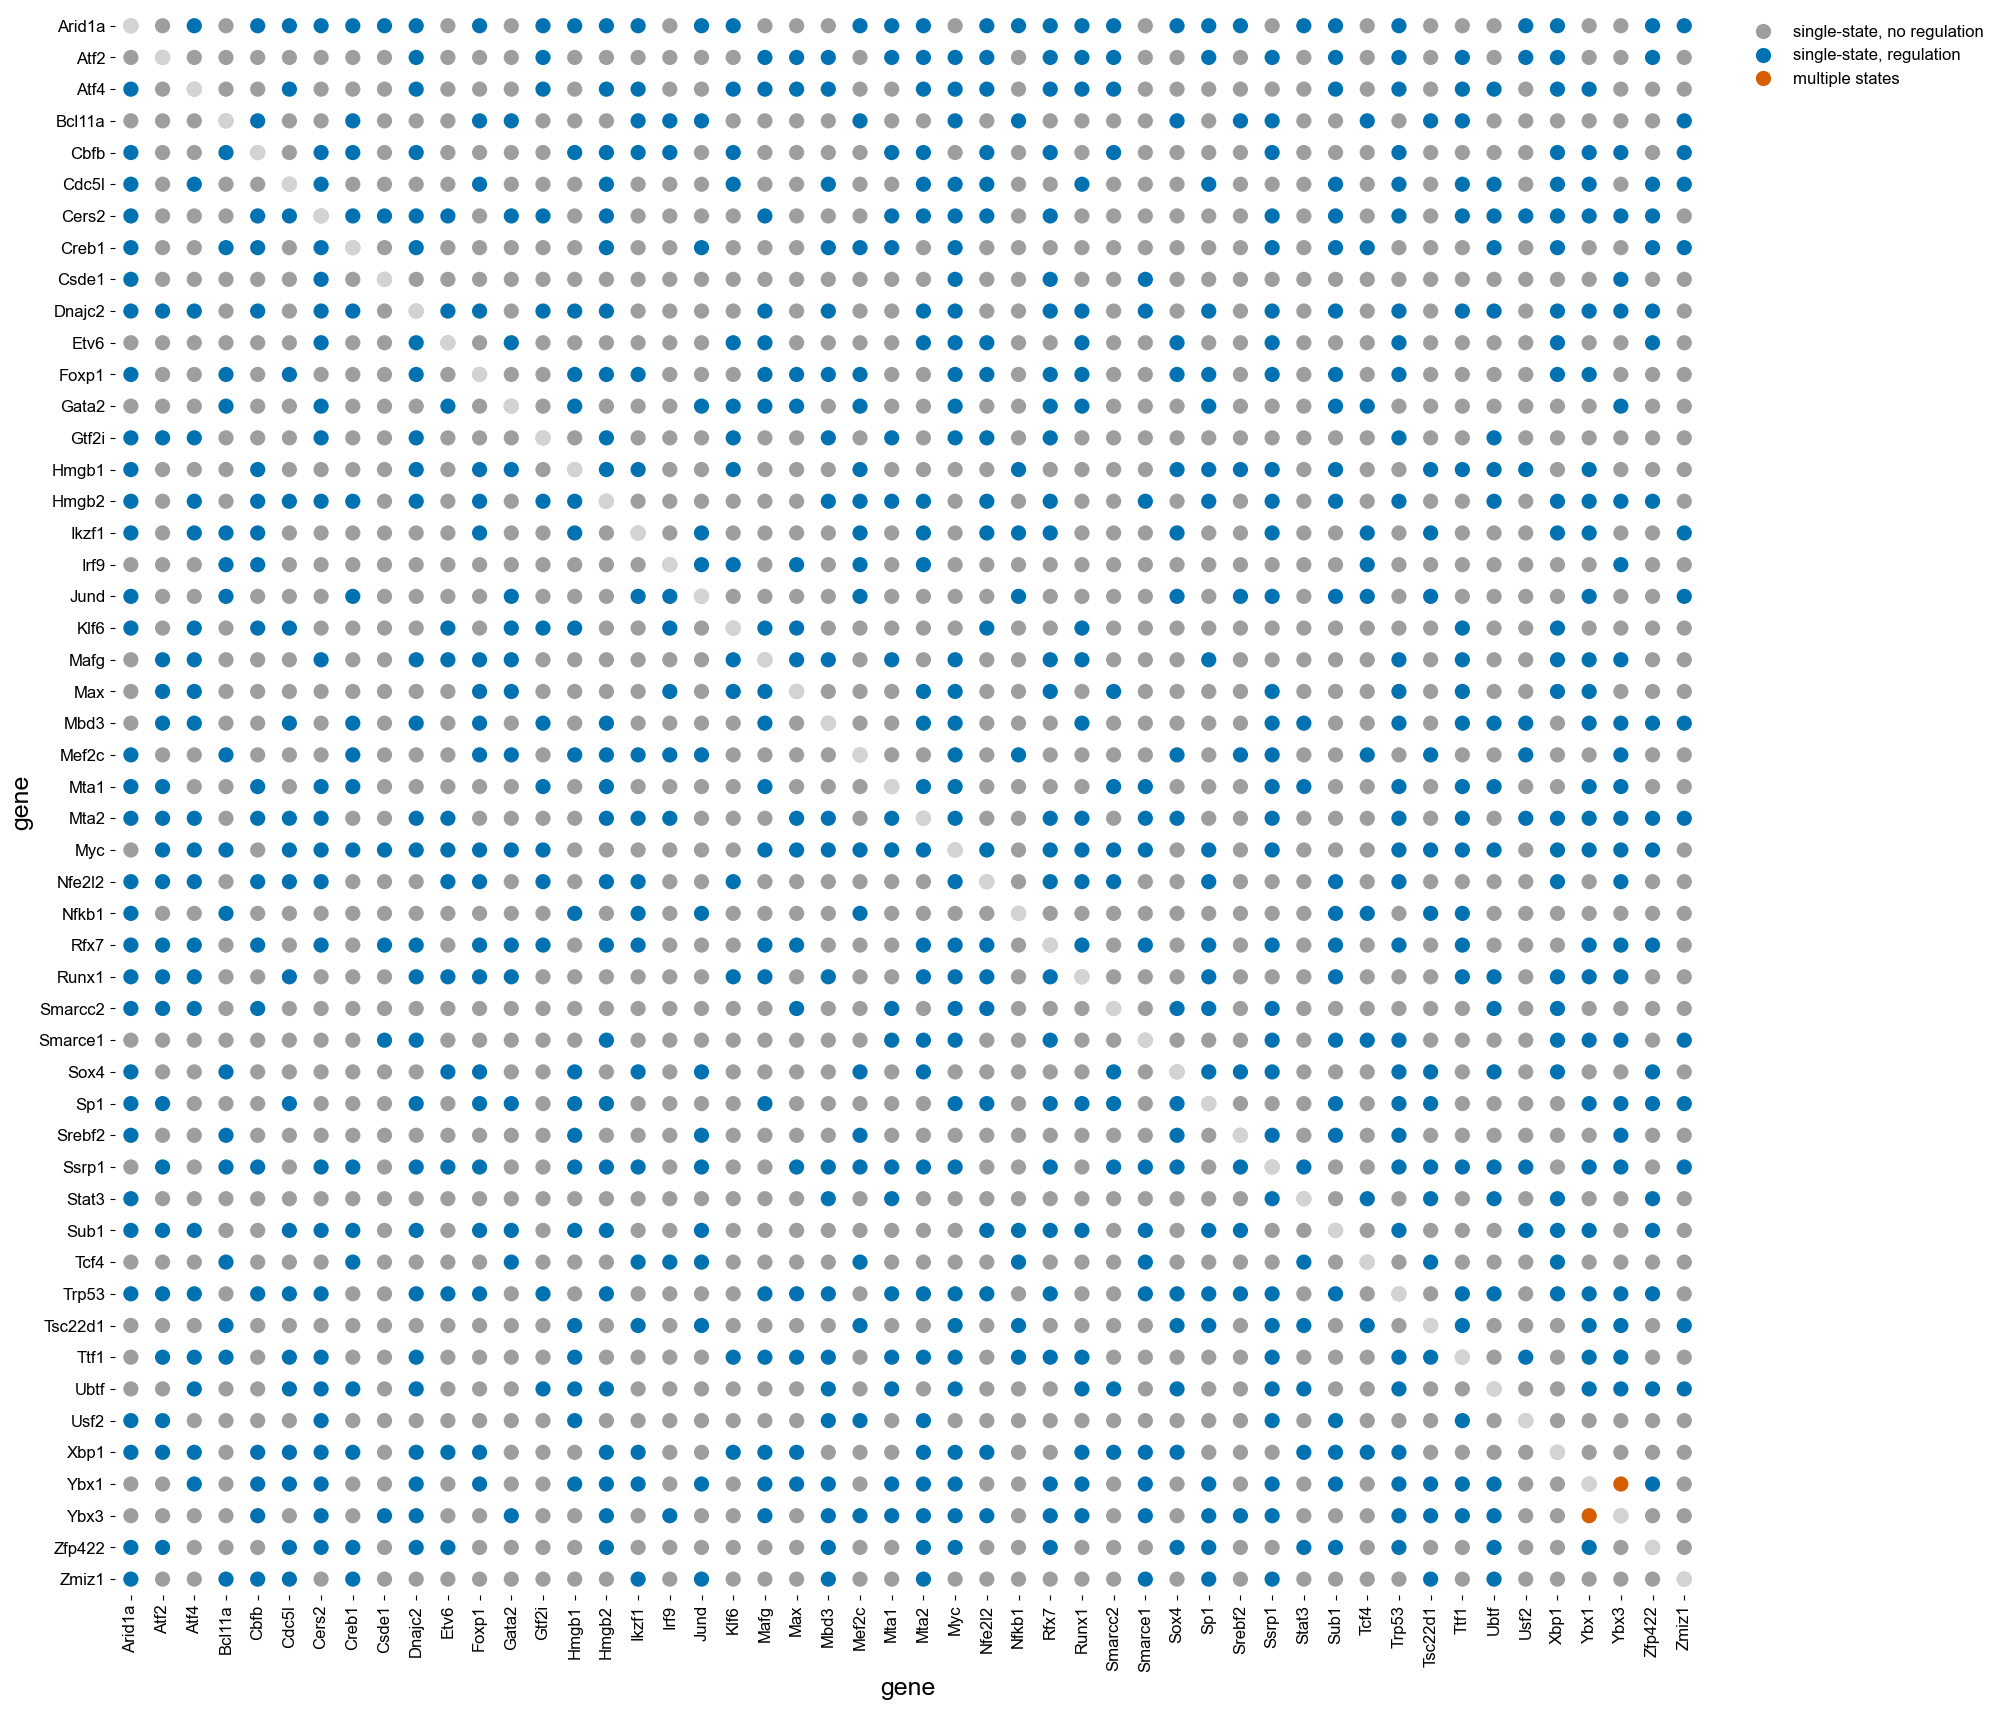

In [16]:
#Gene pair classification - Regulator TF
gene_set_name = "Top_50_genes"
df_pair_classification = pd.read_csv(f"{path_to_plot_data}/all_gene_pair_classification_{gene_set_name}.csv")
pair_sets = {
    "self": {(g, g) for g in gene_list_50_genes }
}

# ----------------------------------
# Normalize pairs
# ----------------------------------
def normalize_pairs(pairs):
    return {tuple(sorted(p)) for p in pairs}

pair_sets = {k: normalize_pairs(v) for k, v in pair_sets.items()}
for scenario in scenario_order:
    if scenario == "self":
        continue

    pairs = df_pair_classification.loc[
        df_pair_classification["scenario"] == scenario,
        ["gene_1", "gene_2"]
    ]

    pair_sets[scenario] = {
        tuple(sorted(p)) for p in pairs.to_numpy()
    }
# ----------------------------------
# Gene list
# ----------------------------------
gene_list = sorted({g for pairs in pair_sets.values() for p in pairs for g in p})

# ----------------------------------
# Build symmetric plotting dataframe
# (EXCLUDE diagonal explicitly)
# ----------------------------------
records = []

for scenario in scenario_order:
    for g1, g2 in pair_sets[scenario]:
        if g1 == g2:
            records.append({"gene_x": g1, "gene_y": g2, "scenario": "self"})
        records.append({"gene_x": g1, "gene_y": g2, "scenario": scenario})
        records.append({"gene_x": g2, "gene_y": g1, "scenario": scenario})

df_plot = pd.DataFrame(records)
from pandas.api.types import CategoricalDtype

gene_cat = CategoricalDtype(categories=gene_list, ordered=True)

df_plot["gene_x"] = df_plot["gene_x"].astype(gene_cat)
df_plot["gene_y"] = df_plot["gene_y"].astype(gene_cat)

# ----------------------------------
# Plot
# ----------------------------------
fig, ax = plt.subplots(figsize=(20, 20))

sns.scatterplot(
    data=df_plot,
    x="gene_x",
    y="gene_y",
    hue="scenario",
    hue_order=scenario_order,
    palette=scenario_colors,
    ax=ax,
    edgecolor = "none",
    linewidth=0,
    s=120
)

handles, labels = ax.get_legend_handles_labels()

# remove "self" from legend
handles_filtered = []
labels_filtered = []

for h, l in zip(handles, labels):
    if l != "self":
        handles_filtered.append(h)
        labels_filtered.append(l)

ax.legend(
    handles_filtered,
    labels_filtered,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)


# ax.set_xticks(range(len(gene_list)))
# ax.set_yticks(range(len(gene_list)))
ax.set_xticklabels(gene_list, rotation=90)
# ax.set_yticklabels(gene_list)
ax.set_ylabel("gene")
ax.set_xlabel("gene")

ax.set_xlim(-0.5, len(gene_list) - 0.5)
ax.set_ylim(len(gene_list) - 0.5, -0.5)
ax.set_aspect("equal")


sns.despine(left=True, bottom=True)
plt.tight_layout()
save_path = f"{path_to_plots}/day_2_{gene_set_name}_scenarios.pdf"
plt.savefig(save_path, 
           format='pdf', 
           bbox_inches='tight',
           facecolor='none',      # Transparent figure background
           edgecolor='none',      # No edge color
           transparent=True)      # Ensure transparency
plt.show()

/tmp/ipykernel_303465/799509804.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(gene_list, rotation=90)


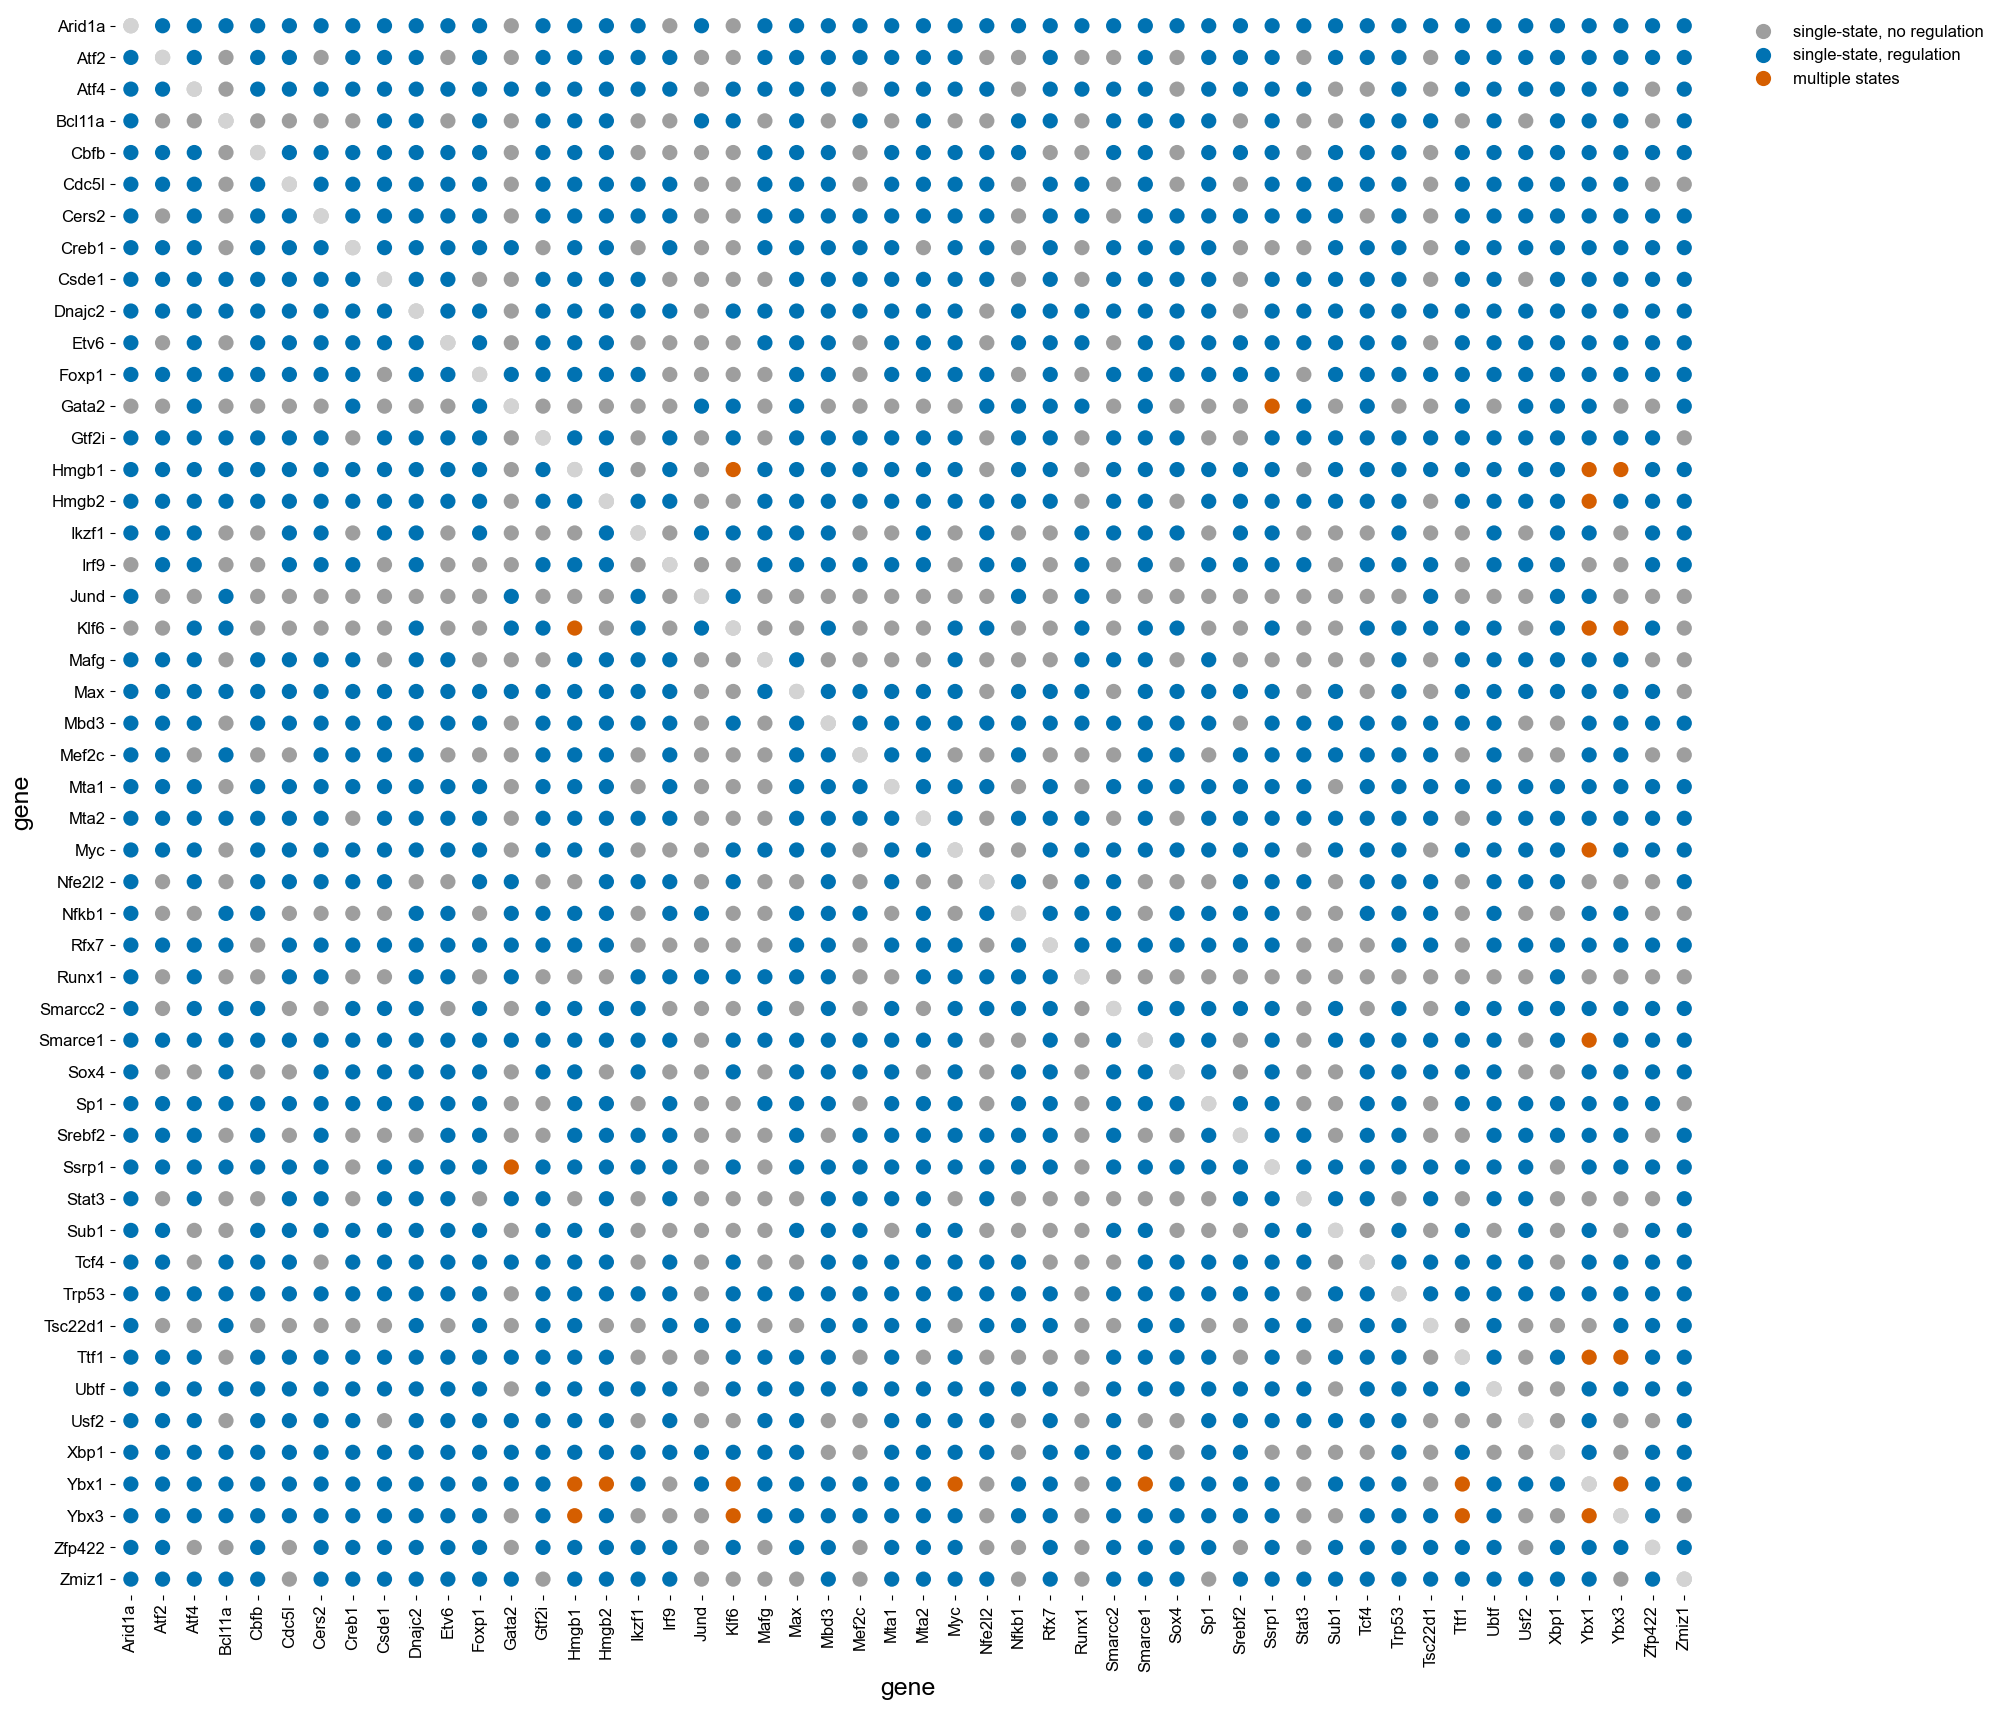

In [17]:
#Gene pair classification - Regulator TF
gene_set_name = "Top_50_genes"
df_pair_classification = pd.read_csv(f"{path_to_plot_data}/all_gene_pair_classification_{gene_set_name}_day_4.csv")
pair_sets = {
    "self": {(g, g) for g in gene_list_50_genes }
}

# ----------------------------------
# Normalize pairs
# ----------------------------------
def normalize_pairs(pairs):
    return {tuple(sorted(p)) for p in pairs}

pair_sets = {k: normalize_pairs(v) for k, v in pair_sets.items()}
for scenario in scenario_order:
    if scenario == "self":
        continue

    pairs = df_pair_classification.loc[
        df_pair_classification["scenario"] == scenario,
        ["gene_1", "gene_2"]
    ]

    pair_sets[scenario] = {
        tuple(sorted(p)) for p in pairs.to_numpy()
    }
# ----------------------------------
# Gene list
# ----------------------------------
gene_list = sorted({g for pairs in pair_sets.values() for p in pairs for g in p})

# ----------------------------------
# Build symmetric plotting dataframe
# (EXCLUDE diagonal explicitly)
# ----------------------------------
records = []

for scenario in scenario_order:
    for g1, g2 in pair_sets[scenario]:
        if g1 == g2:
            records.append({"gene_x": g1, "gene_y": g2, "scenario": "self"})
        records.append({"gene_x": g1, "gene_y": g2, "scenario": scenario})
        records.append({"gene_x": g2, "gene_y": g1, "scenario": scenario})

df_plot = pd.DataFrame(records)
from pandas.api.types import CategoricalDtype

gene_cat = CategoricalDtype(categories=gene_list, ordered=True)

df_plot["gene_x"] = df_plot["gene_x"].astype(gene_cat)
df_plot["gene_y"] = df_plot["gene_y"].astype(gene_cat)

# ----------------------------------
# Plot
# ----------------------------------
fig, ax = plt.subplots(figsize=(20, 20))

sns.scatterplot(
    data=df_plot,
    x="gene_x",
    y="gene_y",
    hue="scenario",
    hue_order=scenario_order,
    palette=scenario_colors,
    ax=ax,
    edgecolor = "none",
    linewidth=0,
    s=120
)

handles, labels = ax.get_legend_handles_labels()

# remove "self" from legend
handles_filtered = []
labels_filtered = []

for h, l in zip(handles, labels):
    if l != "self":
        handles_filtered.append(h)
        labels_filtered.append(l)

ax.legend(
    handles_filtered,
    labels_filtered,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)


# ax.set_xticks(range(len(gene_list)))
# ax.set_yticks(range(len(gene_list)))
ax.set_xticklabels(gene_list, rotation=90)
# ax.set_yticklabels(gene_list)
ax.set_ylabel("gene")
ax.set_xlabel("gene")

ax.set_xlim(-0.5, len(gene_list) - 0.5)
ax.set_ylim(len(gene_list) - 0.5, -0.5)
ax.set_aspect("equal")


sns.despine(left=True, bottom=True)
plt.tight_layout()
save_path = f"{path_to_plots}/day_4_{gene_set_name}_scenarios.pdf"
plt.savefig(save_path, 
           format='pdf', 
           bbox_inches='tight',
           facecolor='none',      # Transparent figure background
           edgecolor='none',      # No edge color
           transparent=True)      # Ensure transparency
plt.show()

/tmp/ipykernel_3573017/2399510999.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(gene_list, rotation=90)


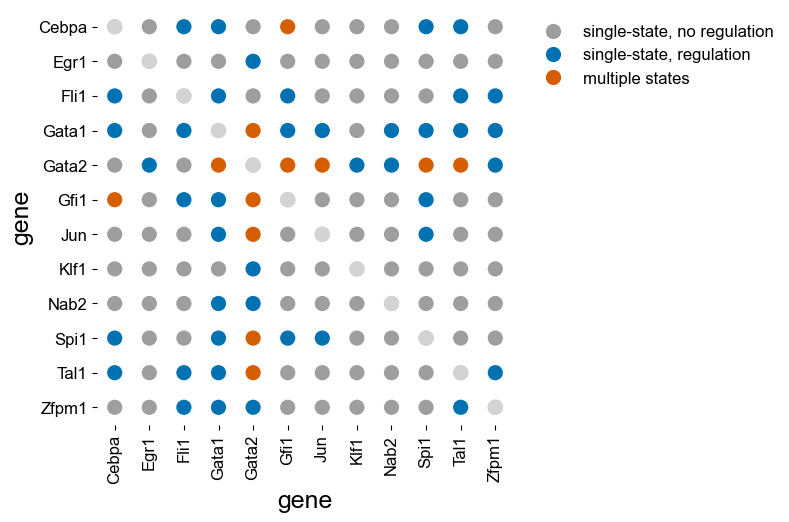

In [9]:
#Gene pair classification - Regulator TF
gene_set_name = "Regulator_TF"
df_pair_classification = pd.read_csv(f"{path_to_plot_data}/all_gene_pair_classification_{gene_set_name}_day_4.csv")
pair_sets = {
    "self": {(g, g) for g in gene_list_Regulator_TF}
}

# ----------------------------------
# Normalize pairs
# ----------------------------------
def normalize_pairs(pairs):
    return {tuple(sorted(p)) for p in pairs}

pair_sets = {k: normalize_pairs(v) for k, v in pair_sets.items()}
for scenario in scenario_order:
    if scenario == "self":
        continue

    pairs = df_pair_classification.loc[
        df_pair_classification["scenario"] == scenario,
        ["gene_1", "gene_2"]
    ]

    pair_sets[scenario] = {
        tuple(sorted(p)) for p in pairs.to_numpy()
    }
# ----------------------------------
# Gene list
# ----------------------------------
gene_list = sorted({g for pairs in pair_sets.values() for p in pairs for g in p})

# ----------------------------------
# Build symmetric plotting dataframe
# (EXCLUDE diagonal explicitly)
# ----------------------------------
records = []

for scenario in scenario_order:
    for g1, g2 in pair_sets[scenario]:
        if g1 == g2:
            records.append({"gene_x": g1, "gene_y": g2, "scenario": "self"})
        records.append({"gene_x": g1, "gene_y": g2, "scenario": scenario})
        records.append({"gene_x": g2, "gene_y": g1, "scenario": scenario})

df_plot = pd.DataFrame(records)
from pandas.api.types import CategoricalDtype

gene_cat = CategoricalDtype(categories=gene_list, ordered=True)

df_plot["gene_x"] = df_plot["gene_x"].astype(gene_cat)
df_plot["gene_y"] = df_plot["gene_y"].astype(gene_cat)

# ----------------------------------
# Plot
# ----------------------------------
fig, ax = plt.subplots(figsize=(8, 8))

sns.scatterplot(
    data=df_plot,
    x="gene_x",
    y="gene_y",
    hue="scenario",
    hue_order=scenario_order,
    palette=scenario_colors,
    ax=ax,
    edgecolor = "none",
    linewidth=0,
    s=120
)

handles, labels = ax.get_legend_handles_labels()

# remove "self" from legend
handles_filtered = []
labels_filtered = []

for h, l in zip(handles, labels):
    if l != "self":
        handles_filtered.append(h)
        labels_filtered.append(l)

ax.legend(
    handles_filtered,
    labels_filtered,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)


# ax.set_xticks(range(len(gene_list)))
# ax.set_yticks(range(len(gene_list)))
ax.set_xticklabels(gene_list, rotation=90)
# ax.set_yticklabels(gene_list)
ax.set_ylabel("gene")
ax.set_xlabel("gene")

ax.set_xlim(-0.5, len(gene_list) - 0.5)
ax.set_ylim(len(gene_list) - 0.5, -0.5)
ax.set_aspect("equal")


sns.despine(left=True, bottom=True)
plt.tight_layout()
save_path = f"{path_to_plots}/day_4_{gene_set_name}_scenarios.pdf"
plt.savefig(save_path, 
           format='pdf', 
           bbox_inches='tight',
           facecolor='none',      # Transparent figure background
           edgecolor='none',      # No edge color
           transparent=True)      # Ensure transparency
plt.show()

In [ ]:
#Gene pair classification - Regulator TF
gene_set_name = "Neutrophil"
df_pair_classification = pd.read_csv(f"{path_to_plot_data}/all_gene_pair_classification_{gene_set_name}.csv")
pair_sets = {
    "self": {(g, g) for g in gene_list_Neutrophil}
}

# ----------------------------------
# Normalize pairs
# ----------------------------------
def normalize_pairs(pairs):
    return {tuple(sorted(p)) for p in pairs}

pair_sets = {k: normalize_pairs(v) for k, v in pair_sets.items()}
for scenario in scenario_order:
    if scenario == "self":
        continue

    pairs = df_pair_classification.loc[
        df_pair_classification["scenario"] == scenario,
        ["gene_1", "gene_2"]
    ]

    pair_sets[scenario] = {
        tuple(sorted(p)) for p in pairs.to_numpy()
    }
# ----------------------------------
# Gene list
# ----------------------------------
gene_list = sorted({g for pairs in pair_sets.values() for p in pairs for g in p})

# ----------------------------------
# Build symmetric plotting dataframe
# (EXCLUDE diagonal explicitly)
# ----------------------------------
records = []

for scenario in scenario_order:
    for g1, g2 in pair_sets[scenario]:
        if g1 == g2:
            records.append({"gene_x": g1, "gene_y": g2, "scenario": "self"})
        records.append({"gene_x": g1, "gene_y": g2, "scenario": scenario})
        records.append({"gene_x": g2, "gene_y": g1, "scenario": scenario})

df_plot = pd.DataFrame(records)
from pandas.api.types import CategoricalDtype

gene_cat = CategoricalDtype(categories=gene_list, ordered=True)

df_plot["gene_x"] = df_plot["gene_x"].astype(gene_cat)
df_plot["gene_y"] = df_plot["gene_y"].astype(gene_cat)

# ----------------------------------
# Plot
# ----------------------------------
fig, ax = plt.subplots(figsize=(8, 8))

sns.scatterplot(
    data=df_plot,
    x="gene_x",
    y="gene_y",
    hue="scenario",
    hue_order=scenario_order,
    palette=scenario_colors,
    ax=ax,
    edgecolor = "none",
    linewidth=0,
    s=120
)

handles, labels = ax.get_legend_handles_labels()

# remove "self" from legend
handles_filtered = []
labels_filtered = []

for h, l in zip(handles, labels):
    if l != "self":
        handles_filtered.append(h)
        labels_filtered.append(l)

ax.legend(
    handles_filtered,
    labels_filtered,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)


# ax.set_xticks(range(len(gene_list)))
# ax.set_yticks(range(len(gene_list)))
ax.set_xticklabels(gene_list, rotation=90)
# ax.set_yticklabels(gene_list)
ax.set_ylabel("gene")
ax.set_xlabel("gene")

ax.set_xlim(-0.5, len(gene_list) - 0.5)
ax.set_ylim(len(gene_list) - 0.5, -0.5)
ax.set_aspect("equal")


sns.despine(left=True, bottom=True)
plt.tight_layout()
save_path = f"{path_to_plots}/day_2_{gene_set_name}_scenarios.pdf"
plt.savefig(save_path, 
           format='pdf', 
           bbox_inches='tight',
           facecolor='none',      # Transparent figure background
           edgecolor='none',      # No edge color
           transparent=True)      # Ensure transparency
plt.show()

## Figure 5e

In [18]:
# === Load saved CSV ===
gene_set_name = "Top_50_genes"
df = pd.read_csv(path_to_plot_data / f"gene_pair_results_{gene_set_name}.csv")

# === Reconstruct lists and matrices ===
no_regulation = {}
potential_regulation = {}
pairwise_gene_gene_correlation_matrix = {}

for tp, sub in df.groupby("timepoint"):
    # Lists of tuples
    no_regulation[tp] = list(zip(sub.loc[sub["category"] == "no_regulation", "gene_1"],
                                 sub.loc[sub["category"] == "no_regulation", "gene_2"]))
    potential_regulation[tp] = list(zip(sub.loc[sub["category"] == "potential_regulation", "gene_1"],
                                        sub.loc[sub["category"] == "potential_regulation", "gene_2"]))
    # Pivot to matrix
    corr_mat = sub.pivot_table(index="gene_1", columns="gene_2", values="correlation")
    # make symmetric since we only stored one order per pair
    corr_mat = corr_mat.combine_first(corr_mat.T)
    pairwise_gene_gene_correlation_matrix[tp] = corr_mat

# === Extract t1, t2, t3 structures ===
no_regulation_t1 = no_regulation["t1"]
no_regulation_t2 = no_regulation["t2"]
no_regulation_t3 = no_regulation["t3"]

potential_regulation_t1 = potential_regulation["t1"]
potential_regulation_t2 = potential_regulation["t2"]
potential_regulation_t3 = potential_regulation["t3"]

pairwise_gene_gene_correlation_matrix_t1 = pairwise_gene_gene_correlation_matrix["t1"]
pairwise_gene_gene_correlation_matrix_t2 = pairwise_gene_gene_correlation_matrix["t2"]
pairwise_gene_gene_correlation_matrix_t3 = pairwise_gene_gene_correlation_matrix["t3"]

# Optional sanity check
for tp in ["t1", "t2", "t3"]:
    print(f"{tp}: {len(no_regulation[tp])} no-reg pairs, "
          f"{len(potential_regulation[tp])} potential-reg pairs, "
          f"matrix {pairwise_gene_gene_correlation_matrix[tp].shape}")

consistent_pairs = (
    set(potential_regulation_t1)
    & set(potential_regulation_t2)
    & set(potential_regulation_t3)
)

consistent_corr = []

for g1, g2 in consistent_pairs:
    # optional: enforce ordering to avoid (A,B) vs (B,A)
    g1, g2 = sorted((g1, g2))

    c1 = pairwise_gene_gene_correlation_matrix_t1.loc[g1, g2]
    c2 = pairwise_gene_gene_correlation_matrix_t2.loc[g1, g2]
    c3 = pairwise_gene_gene_correlation_matrix_t3.loc[g1, g2]

    # ignore zero / NaN correlations
    if any(np.isnan([c1, c2, c3])) or any(c == 0 for c in (c1, c2, c3)):
        continue

    if np.sign(c1) == np.sign(c2) == np.sign(c3):
        consistent_corr.append((g1, g2))
consistent_corr = sorted(consistent_corr)

t1: 732 no-reg pairs, 493 potential-reg pairs, matrix (50, 50)
t2: 349 no-reg pairs, 876 potential-reg pairs, matrix (50, 50)
t3: 35 no-reg pairs, 1190 potential-reg pairs, matrix (50, 50)


In [23]:
pairwise_gene_gene_correlation_matrix_t3.shape

(50, 50)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


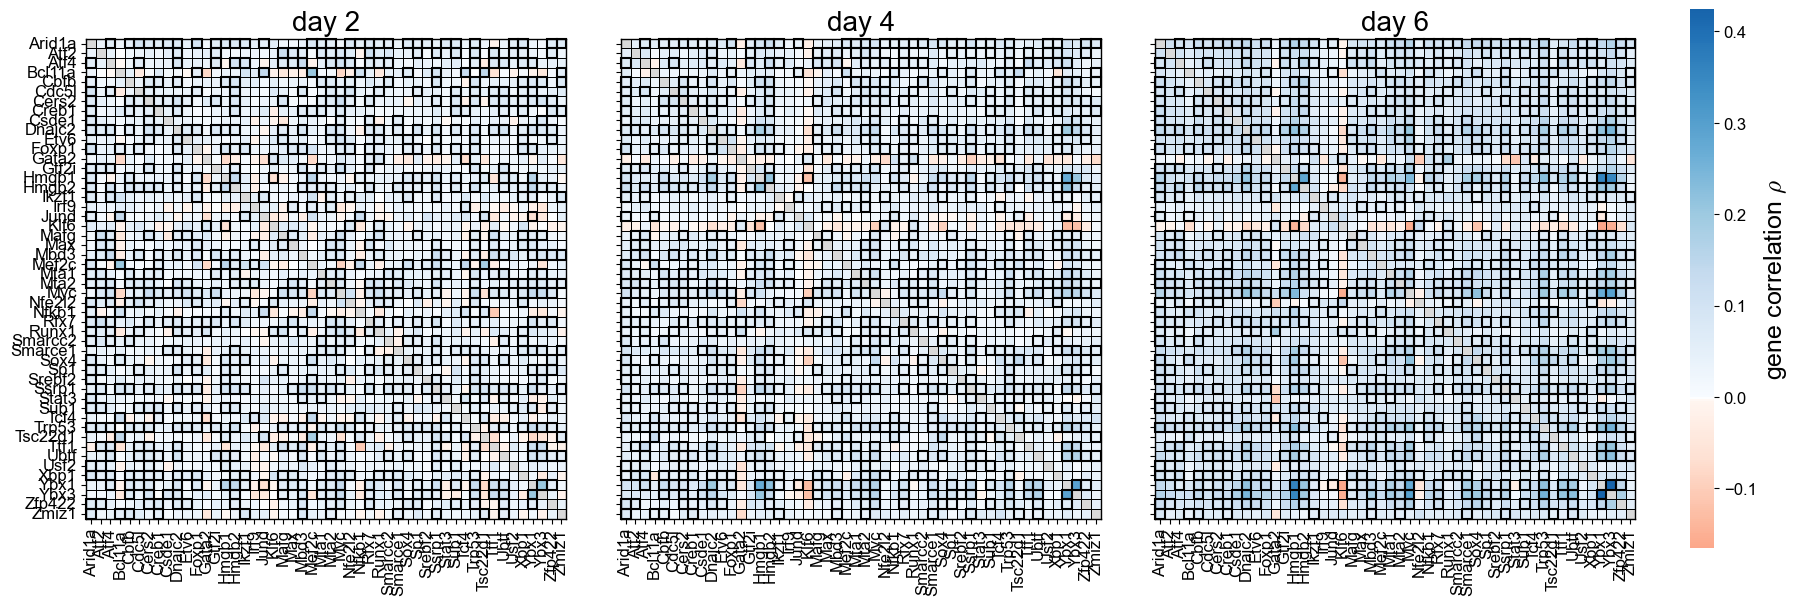

In [27]:
# ----------------------------- 
# Setup 
# ----------------------------- 
gene_list = sorted(gene_list_50_genes)
corr_mats = {
    "day 2": pairwise_gene_gene_correlation_matrix_t1,
    "day 4": pairwise_gene_gene_correlation_matrix_t2,
    "day 6": pairwise_gene_gene_correlation_matrix_t3,
}

# ----------------------------- 
# Figure layout: 3 plots + vertical cbar 
# ----------------------------- 
fig = plt.figure(figsize=(21, 7))
gs = fig.add_gridspec(
    1, 4,
    width_ratios=[1, 1, 1, 0.05],
    wspace=0.15
)
axes = [fig.add_subplot(gs[0, 0])]
axes += [fig.add_subplot(gs[0, i], sharey=axes[0]) for i in range(1, 3)]
cbar_ax = fig.add_subplot(gs[0, 3])

# --- compute global vmin / vmax across all timepoints ---
all_values = []
for corr_df in [
    pairwise_gene_gene_correlation_matrix_t1,
    pairwise_gene_gene_correlation_matrix_t2,
    pairwise_gene_gene_correlation_matrix_t3,
]:
    mat = corr_df.loc[gene_list, gene_list].to_numpy(float)
    np.fill_diagonal(mat, np.nan)
    all_values.append(mat)

all_values = np.concatenate([m.flatten() for m in all_values])
vmin = min(0.0, np.nanmin(all_values))
vmax = np.nanmax(all_values)
cmap = make_reds_blues_colormap(vmin=vmin, vmax=vmax)
cmap.set_bad("#D9D9D9")

# ----------------------------- 
# Plot heatmaps 
# ----------------------------- 
for ax, (label, corr_df) in zip(axes, corr_mats.items()):
    data_matrix = corr_df.loc[gene_list, gene_list].to_numpy(float)
    np.fill_diagonal(data_matrix, np.nan)
    
    sns.heatmap(
        data_matrix,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        square=True,
        cbar=(ax is axes[0]),
        cbar_ax=cbar_ax if ax is axes[0] else None,
        cbar_kws={'orientation': 'vertical'},
        linewidths=0.5,
        linecolor="black",
    )
    
    ax.set_title(label)
    
    # Fix: Set ticks explicitly before setting labels
    ax.set_xticks(np.arange(len(gene_list)) + 0.5)
    ax.set_xticklabels(gene_list, rotation=90, ha="center", va="top")
    
    # ----------------------------- 
    # Thick boxes for consistent pairs 
    # ----------------------------- 
    for g1, g2 in consistent_corr:
        if g1 in gene_list and g2 in gene_list:
            i = gene_list.index(g1)
            j = gene_list.index(g2)
            for (x, y) in [(j, i), (i, j)]:
                rect = Rectangle(
                    (x, y), 1, 1,
                    fill=False,
                    edgecolor="black",
                    linewidth=1.5
                )
                rect.set_clip_on(False)
                ax.add_patch(rect)
    
    # Illustrator-safe cleanup
    ax.set_facecolor("none")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_edgecolor("black")
        spine.set_clip_on(False)

# ----------------------------- 
# Colorbar formatting 
# ----------------------------- 
cbar_ax.set_ylabel(r"gene correlation ${\rho}$")
cbar_ax.set_facecolor("none")

# --- keep y labels ONLY on the leftmost axis ---
axes[0].set_yticks(np.arange(len(gene_list)) + 0.5)
axes[0].set_yticklabels(gene_list, rotation=0, ha="right", va="center")
axes[0].tick_params(labelleft=True)

for ax in axes[1:]:
    ax.tick_params(labelleft=False)

# ----------------------------- 
# Save 
# ----------------------------- 
if path_to_plots:
    out = Path(path_to_plots)
    out.mkdir(parents=True, exist_ok=True)
    base = out / f"gene_correlation_{gene_set_name}"
    fig.savefig(f"{base}.png", dpi=300, bbox_inches="tight", transparent=True)
    fig.savefig(f"{base}.svg", bbox_inches="tight", transparent=True)
    fig.savefig(f"{base}.pdf", bbox_inches="tight", transparent=True)
plt.show()

## Figure 5f

In [28]:
# === Load saved CSV ===
gene_set_name = "Top_50_genes"
df = pd.read_csv(path_to_plot_data / f"gene_pair_results_{gene_set_name}.csv")

# === Reconstruct lists and matrices ===
no_regulation = {}
potential_regulation = {}
pairwise_gene_gene_correlation_matrix = {}

for tp, sub in df.groupby("timepoint"):
    # Lists of tuples
    no_regulation[tp] = list(zip(sub.loc[sub["category"] == "no_regulation", "gene_1"],
                                 sub.loc[sub["category"] == "no_regulation", "gene_2"]))
    potential_regulation[tp] = list(zip(sub.loc[sub["category"] == "potential_regulation", "gene_1"],
                                        sub.loc[sub["category"] == "potential_regulation", "gene_2"]))
    # Pivot to matrix
    corr_mat = sub.pivot_table(index="gene_1", columns="gene_2", values="correlation")
    # make symmetric since we only stored one order per pair
    corr_mat = corr_mat.combine_first(corr_mat.T)
    pairwise_gene_gene_correlation_matrix[tp] = corr_mat

# === Extract t1, t2, t3 structures ===
no_regulation_t1 = no_regulation["t1"]
no_regulation_t2 = no_regulation["t2"]
no_regulation_t3 = no_regulation["t3"]

potential_regulation_t1 = potential_regulation["t1"]
potential_regulation_t2 = potential_regulation["t2"]
potential_regulation_t3 = potential_regulation["t3"]

pairwise_gene_gene_correlation_matrix_t1 = pairwise_gene_gene_correlation_matrix["t1"]
pairwise_gene_gene_correlation_matrix_t2 = pairwise_gene_gene_correlation_matrix["t2"]
pairwise_gene_gene_correlation_matrix_t3 = pairwise_gene_gene_correlation_matrix["t3"]

# Optional sanity check
for tp in ["t1", "t2", "t3"]:
    print(f"{tp}: {len(no_regulation[tp])} no-reg pairs, "
          f"{len(potential_regulation[tp])} potential-reg pairs, "
          f"matrix {pairwise_gene_gene_correlation_matrix[tp].shape}")

consistent_pairs = (
    set(potential_regulation_t1)
    & set(potential_regulation_t2)
    & set(potential_regulation_t3)
)

consistent_corr = []

for g1, g2 in consistent_pairs:
    # optional: enforce ordering to avoid (A,B) vs (B,A)
    g1, g2 = sorted((g1, g2))

    c1 = pairwise_gene_gene_correlation_matrix_t1.loc[g1, g2]
    c2 = pairwise_gene_gene_correlation_matrix_t2.loc[g1, g2]
    c3 = pairwise_gene_gene_correlation_matrix_t3.loc[g1, g2]

    # ignore zero / NaN correlations
    if any(np.isnan([c1, c2, c3])) or any(c == 0 for c in (c1, c2, c3)):
        continue

    if np.sign(c1) == np.sign(c2) == np.sign(c3):
        consistent_corr.append((g1, g2))
consistent_corr = sorted(consistent_corr)

t1: 732 no-reg pairs, 493 potential-reg pairs, matrix (50, 50)
t2: 349 no-reg pairs, 876 potential-reg pairs, matrix (50, 50)
t3: 35 no-reg pairs, 1190 potential-reg pairs, matrix (50, 50)


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved PNG: /home/gzu5140/Keerthana_b1042/grnInference/plots/figure_5_myeloid_progenitors_50_TF/gene_correlation_day_2_Top_50_genes.png
Saved SVG: /home/gzu5140/Keerthana_b1042/grnInference/plots/figure_5_myeloid_progenitors_50_TF/gene_correlation_day_2_Top_50_genes.svg


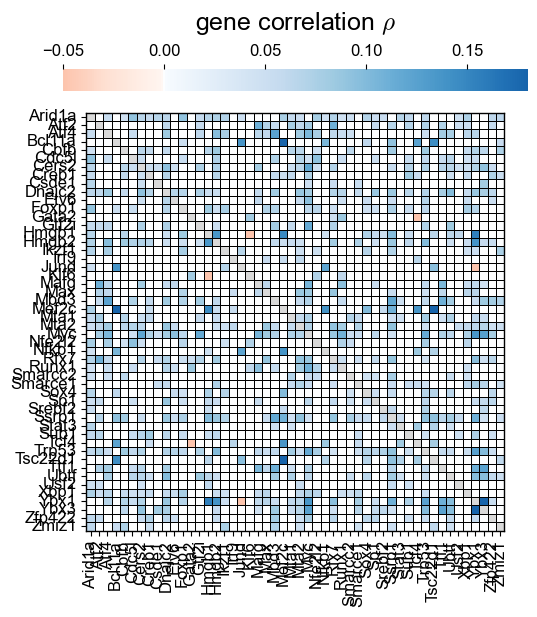

In [30]:
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from matplotlib.colors import ListedColormap

gene_list = sorted(gene_list_50_genes)
correlation_matrix = pairwise_gene_gene_correlation_matrix_t1.loc[gene_list, gene_list]
data_matrix = correlation_matrix.to_numpy(float)

masked_matrix = np.fill_diagonal(data_matrix, np.nan)
fig = plt.figure(figsize=(6,6))
gs = fig.add_gridspec(2, 1, height_ratios=[0.05, 0.95], hspace=0.1)
cbar_ax = fig.add_subplot(gs[0])
heatmap_ax = fig.add_subplot(gs[1])

# Start by zeroing everything
plot_matrix = data_matrix.copy()
plot_matrix[:] = 0.0

# Restore only consistent correlations
for g1, g2 in consistent_corr:
    if g1 in gene_list and g2 in gene_list:
        i = gene_list.index(g1)
        j = gene_list.index(g2)
        plot_matrix[i, j] = data_matrix[i, j]
        plot_matrix[j, i] = data_matrix[j, i]

vmin = -0.05
vmax = 0.18
cmap = make_reds_blues_colormap(vmin=vmin, vmax=vmax)
# Restore diagonal NaNs
np.fill_diagonal(plot_matrix, np.nan)
cmap.set_bad(color="#D9D9D9")

# --- draw heatmap ---
sns.heatmap(
    plot_matrix,
    ax=heatmap_ax,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    square=True,
    cbar=True,
    cbar_ax=cbar_ax,
    cbar_kws={'orientation': 'horizontal'},
    linewidths=0.5,
    linecolor="black",
)

# --- labels ---
cbar_ax.xaxis.set_label_position('top')
cbar_ax.set_xlabel(r"gene correlation ${\rho}$", labelpad=10)
cbar_ax.xaxis.tick_top()

# Fix: Set ticks explicitly before setting labels
heatmap_ax.set_xticks(np.arange(len(gene_list)) + 0.5)
heatmap_ax.set_xticklabels(gene_list, rotation=90, ha="center", va="top")
heatmap_ax.set_yticks(np.arange(len(gene_list)) + 0.5)
heatmap_ax.set_yticklabels(gene_list, rotation=0, ha="right", va="center")

# --- transparent background ---
fig.patch.set_alpha(0)
for ax in [heatmap_ax, cbar_ax]:
    ax.set_facecolor("none")
for im in heatmap_ax.get_images() + cbar_ax.get_images():
    im.set_facecolor((1, 1, 1, 0))
    im.set_edgecolor((1, 1, 1, 0))

# Add border by adjusting spine visibility
for spine in heatmap_ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_edgecolor('black')
    spine.set_clip_on(False)

# --- save ---
if path_to_plots:
    out = Path(path_to_plots)
    out.mkdir(parents=True, exist_ok=True)
    matrix_type = "gene_correlation_day_2"
    png_path = out / f"{matrix_type}_{gene_set_name}.png"
    svg_path = out / f"{matrix_type}_{gene_set_name}.svg"
    pdf_path = out / f"{matrix_type}_{gene_set_name}.pdf"
    plt.savefig(png_path, dpi=300, bbox_inches='tight', transparent=True)
    fig.savefig(svg_path, bbox_inches='tight', transparent=True,
                facecolor='none', edgecolor='none', format='svg')
    fig.savefig(pdf_path, bbox_inches='tight', transparent=True,
                facecolor='none', edgecolor='none', format='pdf')
    print(f"Saved PNG: {png_path}")
    print(f"Saved SVG: {svg_path}")

plt.show()

[('Arid1a', 'Atf4'),
 ('Arid1a', 'Cbfb'),
 ('Arid1a', 'Cdc5l'),
 ('Arid1a', 'Cers2'),
 ('Arid1a', 'Creb1'),
 ('Arid1a', 'Csde1'),
 ('Arid1a', 'Dnajc2'),
 ('Arid1a', 'Foxp1'),
 ('Arid1a', 'Gtf2i'),
 ('Arid1a', 'Hmgb1'),
 ('Arid1a', 'Hmgb2'),
 ('Arid1a', 'Ikzf1'),
 ('Arid1a', 'Jund'),
 ('Arid1a', 'Mef2c'),
 ('Arid1a', 'Mta1'),
 ('Arid1a', 'Mta2'),
 ('Arid1a', 'Nfe2l2'),
 ('Arid1a', 'Nfkb1'),
 ('Arid1a', 'Rfx7'),
 ('Arid1a', 'Runx1'),
 ('Arid1a', 'Smarcc2'),
 ('Arid1a', 'Sox4'),
 ('Arid1a', 'Sp1'),
 ('Arid1a', 'Srebf2'),
 ('Arid1a', 'Stat3'),
 ('Arid1a', 'Sub1'),
 ('Arid1a', 'Trp53'),
 ('Arid1a', 'Usf2'),
 ('Arid1a', 'Xbp1'),
 ('Arid1a', 'Zfp422'),
 ('Arid1a', 'Zmiz1'),
 ('Atf2', 'Dnajc2'),
 ('Atf2', 'Gtf2i'),
 ('Atf2', 'Mafg'),
 ('Atf2', 'Max'),
 ('Atf2', 'Mbd3'),
 ('Atf2', 'Mta1'),
 ('Atf2', 'Mta2'),
 ('Atf2', 'Myc'),
 ('Atf2', 'Rfx7'),
 ('Atf2', 'Sp1'),
 ('Atf2', 'Ssrp1'),
 ('Atf2', 'Sub1'),
 ('Atf2', 'Trp53'),
 ('Atf2', 'Ttf1'),
 ('Atf2', 'Usf2'),
 ('Atf2', 'Xbp1'),
 ('Atf2', 'Zfp422'

In [41]:
dict_list = {"TF":[], "Target":[]}
for (i,j) in consistent_corr:
    dict_list['TF'].append(i)
    dict_list['Target'].append(j)

df = pd.DataFrame(dict_list)
df.to_csv(f"{path_to_plot_data}/correlation.csv")

46 47
14 47
26 46
12 36
46 47
14 19
19 46
42 47
32 46
19 47
14 46
42 46
15 46


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved PNG: /home/gzu5140/Keerthana_b1042/grnInference/plots/figure_5_myeloid_progenitors_50_TF/direction_correlation_Top_50_genes.png
Saved SVG: /home/gzu5140/Keerthana_b1042/grnInference/plots/figure_5_myeloid_progenitors_50_TF/direction_correlation_Top_50_genes.svg


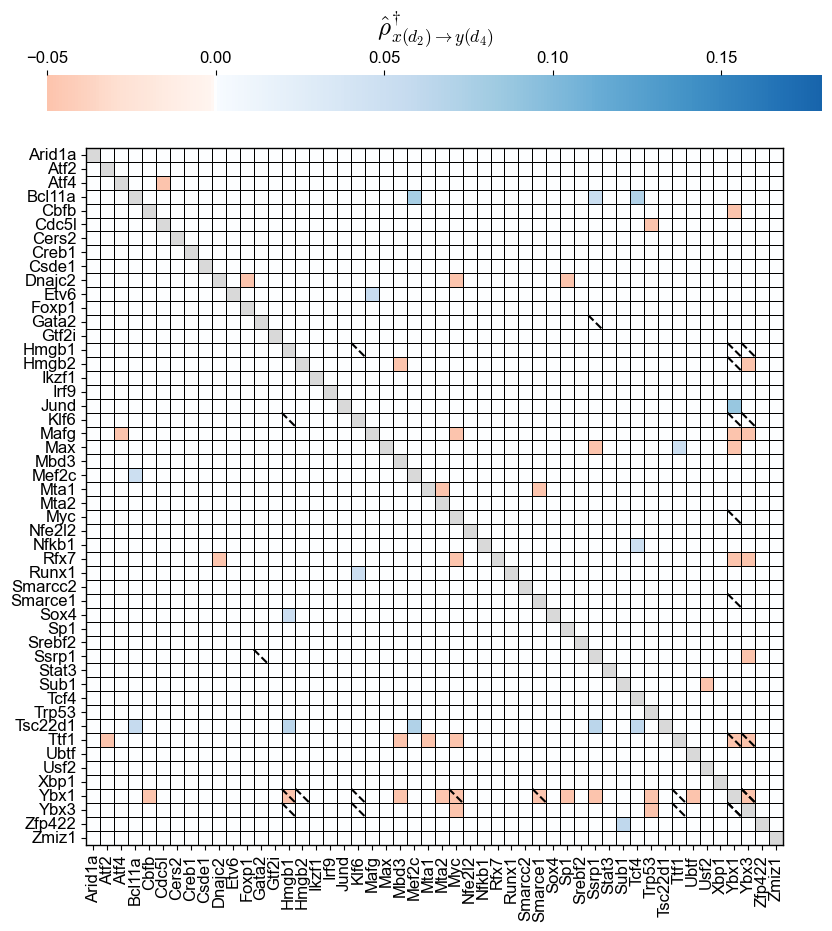

In [33]:
with open(f"{path_to_plot_data}/directional_gene_correlation_data.json") as f:
    directional_gene_correlation_data = json.load(f)

direction_matrix = pd.DataFrame(
    directional_gene_correlation_data["corr_matrix"],
    index=directional_gene_correlation_data["gene_list"],
    columns=directional_gene_correlation_data["gene_list"]
)
gene_list = directional_gene_correlation_data["gene_list"]
multiple_states_and_reg = directional_gene_correlation_data['multi_state_regulation_pairs']
gene_list = sorted(gene_list)
direction_matrix = direction_matrix.loc[gene_list, gene_list]
final_directed_edges = directional_gene_correlation_data['final_directed_edges']
data_matrix = direction_matrix.to_numpy(float)

plot_matrix = data_matrix.copy()
plot_matrix[:] = 0.0

# Restore only consistent correlations
if len(final_directed_edges)>0:
    for g1, g2 in final_directed_edges:
        if g1 in gene_list and g2 in gene_list:
            i = gene_list.index(g1)
            j = gene_list.index(g2)
            plot_matrix[i, j] = data_matrix[i, j]
            plot_matrix[j, i] = data_matrix[j, i]

np.fill_diagonal(plot_matrix, np.nan)


fig = plt.figure(figsize=(10,10))
gs = fig.add_gridspec(2, 1, height_ratios=[0.05, 0.95], hspace=0.1)
cbar_ax = fig.add_subplot(gs[0])
heatmap_ax = fig.add_subplot(gs[1])

cmap = make_reds_blues_colormap()

vmin, vmax = min(0.0, np.nanmin(direction_matrix.values.flatten())), np.nanmax(direction_matrix.values.flatten())
vmin = -0.05
vmax = 0.18
norm = TwoSlopeNorm(vmin=vmin, vmax=vmax, vcenter = 0)

cmap.set_bad(color="#D9D9D9")
# --- draw heatmap ---
sns.heatmap(
    plot_matrix,
    ax=heatmap_ax,
    cmap=cmap,
    # norm = norm,
    vmin=vmin,
    vmax=vmax,
    square=True,
    cbar=True,
    cbar_ax=cbar_ax,
    cbar_kws={'orientation': 'horizontal'},
    linewidths=0.5,
    linecolor="black",
    # center=center
)
for g1, g2 in multiple_states_and_reg:
    if g1 in gene_list and g2 in gene_list:
        i = gene_list.index(g1)
        j = gene_list.index(g2)
        print(i, j)

        # Draw diagonal in cell (i, j) - top-left to bottom-right
        heatmap_ax.plot(
            [j, j+1],      # x: left → right
            [i, i+1],      # y: top → bottom
            linestyle="--",
            color="black",
            linewidth=1.5,
            clip_on=False
        )
        
        # Draw diagonal in symmetric cell (j, i) - top-left to bottom-right
        heatmap_ax.plot(
            [i, i+1],      # x: left → right
            [j, j+1],      # y: top → bottom
            linestyle="--",
            color="black",
            linewidth=1.5,
            clip_on=False
        )
# --- labels ---
cbar_ax.xaxis.set_label_position('top')
cbar_ax.set_xlabel(r"$\hat{\rho}^{\dagger}_{x(d_{2}) \to y(d_{4})}$", labelpad=10)

cbar_ax.xaxis.tick_top()

# Fix: Set ticks explicitly before setting labels
heatmap_ax.set_xticks(np.arange(len(gene_list)) + 0.5)
heatmap_ax.set_xticklabels(gene_list, rotation=90, ha="center", va="top")
heatmap_ax.set_yticks(np.arange(len(gene_list)) + 0.5)
heatmap_ax.set_yticklabels(gene_list, rotation=0, ha="right", va="center")

heatmap_ax.set_xticklabels(gene_list, rotation=90, ha="center", va="top")
heatmap_ax.set_yticklabels(gene_list, rotation=0,ha = "right", va = "center")
# --- transparent background ---
# plt.tight_layout()
fig.patch.set_alpha(0)
for ax in [heatmap_ax, cbar_ax]:
    ax.set_facecolor("none")
for im in heatmap_ax.get_images() + cbar_ax.get_images():
    im.set_facecolor((1, 1, 1, 0))
    im.set_edgecolor((1, 1, 1, 0))
for spine in heatmap_ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_edgecolor('black')
    spine.set_clip_on(False)
# --- save ---
if path_to_plots:
    out = Path(path_to_plots)
    out.mkdir(parents=True, exist_ok=True)
    matrix_type = "direction_correlation"
    png_path = out / f"{matrix_type}_{gene_set_name}.png"
    svg_path = out / f"{matrix_type}_{gene_set_name}.svg"
    pdf_path = out / f"{matrix_type}_{gene_set_name}.pdf"
    plt.savefig(png_path, dpi=300, bbox_inches='tight', transparent=True)
    fig.savefig(svg_path, bbox_inches='tight', transparent=True,
                facecolor='none', edgecolor='none', format='svg')
    fig.savefig(pdf_path, bbox_inches='tight', transparent=True,
                facecolor='none', edgecolor='none', format='pdf')
    print(f"Saved PNG: {png_path}")
    print(f"Saved SVG: {svg_path}")
# # else:
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

Saved PNG: /home/gzu5140/Keerthana_b1042/grnInference/plots/figure_5_myeloid progenitors/random_pair_direction_correlation_Regulator_TF.png
Saved SVG: /home/gzu5140/Keerthana_b1042/grnInference/plots/figure_5_myeloid progenitors/random_pair_direction_correlation_Regulator_TF.svg


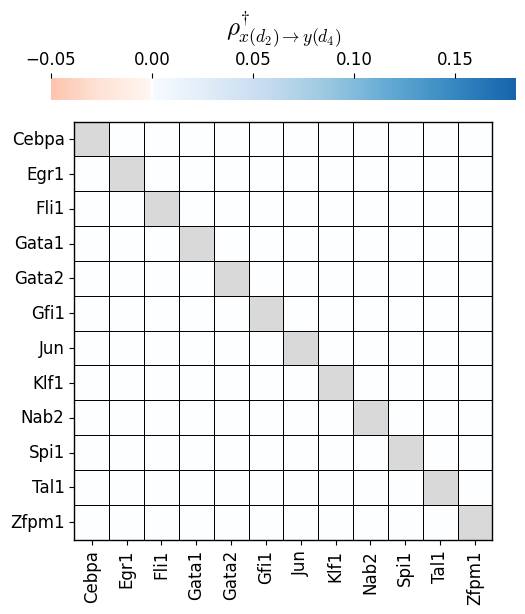

In [26]:
gene_set_name = "Regulator_TF"
with open(f"{path_to_plot_data}/random_pair_directional_gene_correlation_data.json") as f:
    directional_gene_correlation_data = json.load(f)

direction_matrix = pd.DataFrame(
    directional_gene_correlation_data["corr_matrix"],
    index=directional_gene_correlation_data["gene_list"],
    columns=directional_gene_correlation_data["gene_list"]
)

gene_list = directional_gene_correlation_data["gene_list"]
final_directed_edges = directional_gene_correlation_data['final_directed_edges']
multiple_states_and_reg = directional_gene_correlation_data['multi_state_regulation_pairs']
gene_list = sorted(gene_list)
direction_matrix = direction_matrix.loc[gene_list, gene_list]
data_matrix = direction_matrix.to_numpy(float)

plot_matrix = data_matrix.copy()
plot_matrix[:] = 0.0

# Restore only consistent correlations
if len(final_directed_edges)>0:
    for g1, g2 in final_directed_edges:
        if g1 in gene_list and g2 in gene_list:
            i = gene_list.index(g1)
            j = gene_list.index(g2)
            plot_matrix[i, j] = data_matrix[i, j]
            plot_matrix[j, i] = data_matrix[j, i]

np.fill_diagonal(plot_matrix, np.nan)

fig = plt.figure(figsize=(6,6))
gs = fig.add_gridspec(2, 1, height_ratios=[0.05, 0.95], hspace=0.1)
cbar_ax = fig.add_subplot(gs[0])
heatmap_ax = fig.add_subplot(gs[1])


vmin = -0.05
vmax = 0.18
cmap = make_reds_blues_colormap(vmin = vmin, vmax= vmax)

cmap.set_bad(color="#D9D9D9")
# --- draw heatmap ---
sns.heatmap(
    plot_matrix,
    ax=heatmap_ax,
    cmap=cmap,
    # norm = norm,
    vmin=vmin,
    vmax=vmax,
    square=True,
    cbar=True,
    cbar_ax=cbar_ax,
    cbar_kws={'orientation': 'horizontal'},
    linewidths=0.5,
    linecolor="black",
    # center=center
)
for g1, g2 in multiple_states_and_reg:
    if g1 in gene_list and g2 in gene_list:
        i = gene_list.index(g1)
        j = gene_list.index(g2)
        print(i, j)

        # Draw diagonal in cell (i, j) - top-left to bottom-right
        heatmap_ax.plot(
            [j, j+1],      # x: left → right
            [i, i+1],      # y: top → bottom
            linestyle="--",
            color="black",
            linewidth=1.5,
            clip_on=False
        )
        
        # Draw diagonal in symmetric cell (j, i) - top-left to bottom-right
        heatmap_ax.plot(
            [i, i+1],      # x: left → right
            [j, j+1],      # y: top → bottom
            linestyle="--",
            color="black",
            linewidth=1.5,
            clip_on=False
        )
# --- labels ---
cbar_ax.xaxis.set_label_position('top')
cbar_ax.set_xlabel(r"$\rho^{\dagger}_{x(d_{2}) \to y(d_{4})}$", labelpad=10)
cbar_ax.xaxis.tick_top()
heatmap_ax.set_xticklabels(gene_list, rotation=90, ha="center", va="top")
heatmap_ax.set_yticklabels(gene_list, rotation=0,ha = "right", va = "center")
# --- transparent background ---
# plt.tight_layout()
fig.patch.set_alpha(0)
for ax in [heatmap_ax, cbar_ax]:
    ax.set_facecolor("none")
for im in heatmap_ax.get_images() + cbar_ax.get_images():
    im.set_facecolor((1, 1, 1, 0))
    im.set_edgecolor((1, 1, 1, 0))
for spine in heatmap_ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_edgecolor('black')
    spine.set_clip_on(False)
# --- save ---
if path_to_plots:
    out = Path(path_to_plots)
    out.mkdir(parents=True, exist_ok=True)
    matrix_type = "random_pair_direction_correlation"
    png_path = out / f"{matrix_type}_{gene_set_name}.png"
    svg_path = out / f"{matrix_type}_{gene_set_name}.svg"
    pdf_path = out / f"{matrix_type}_{gene_set_name}.pdf"
    plt.savefig(png_path, dpi=300, bbox_inches='tight', transparent=True)
    fig.savefig(svg_path, bbox_inches='tight', transparent=True,
                facecolor='none', edgecolor='none', format='svg')
    fig.savefig(pdf_path, bbox_inches='tight', transparent=True,
                facecolor='none', edgecolor='none', format='pdf')
    print(f"Saved PNG: {png_path}")
    print(f"Saved SVG: {svg_path}")
# # else:
plt.show()